# Cosimita: the whole simulation from one YAML file

Every notebook so far has built its run in Python: a detector here, an Earth
there, a list of sources, a spacecraft history, and a simulator wiring them
together. That is the right way to *learn* the pieces. It is a poor way to
*record* a run -- the configuration lives in a cell, and the only way to say
what you simulated is to hand someone the notebook.

This notebook is the last piece: **one file that names the whole run**, and
`InertialSimulator.from_config` to build it.

```python
simulator = InertialSimulator.from_config('run.yaml')
```

Two rules run through the whole schema, and both exist because a configuration
file is read by people:

- **every unit-bearing value is a string astropy parses** -- `"16 cm"`,
  `"1e-3 1/(cm s)"`, `"45 deg"`. There are no bare numbers with an implied
  unit anywhere in the schema.
- **an unknown key is an error, not a warning** -- at every level. A silently
  ignored typo in a configuration file is a debugging nightmare: you change a
  number, nothing happens, and you have no idea why.

There is no console script and no `python -m`: this is a Python API.

In [1]:
from gammaraytoys.sims import (InertialSimulator, Simulator, PointSource, Earth,
                               MonoenergeticSpectrum, SpacecraftHistory,
                               ZenithPointing, SimpleTraditionalReconstructor,
                               scaling_from_config, source_from_config,
                               write_event_csv, read_event_csv)
from gammaraytoys import ToyTracker2D
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import yaml, copy, time, tempfile, os

# Write the configuration and the event file to a scratch directory rather
# than next to the notebook: re-running this should not leave generated data
# in the repository.
scratch = tempfile.mkdtemp(prefix = 'cosimita_')

## 1. The file

This is COMPTELito -- the same instrument as every other notebook in this
series -- in a 400 km circular orbit, looking at a point source on the sky and
at the Earth underneath it.

Two details worth reading before the code runs:

- `layer_positions` is **quoted**. An array-with-a-unit has to be, because an
  unquoted `[300, 0, 1] cm` is not valid YAML at all -- it is a flow sequence
  with trailing text after it, and PyYAML refuses it. (The development plan's
  own sketch of this schema has that bug.)
- the pulsar carries a `scaling` written as an **expression in `t`**. That is
  the one place in this schema where a configuration file gets to hold
  something like code, and Section 3 is about what that costs.

In [2]:
config_text = """
detector:
  type: ToyTracker2D
  material: Ge
  layer_length: 10 m
  layer_positions: "[300, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9] cm"
  layer_thickness: 1 cm
  energy_resolution: 0.03
  energy_threshold: 20 keV

earth:
  radius: 6371 km

random_seed: 0

spacecraft_history:
  type: elliptical_orbit
  semi_major_axis: 6771 km
  duration: 6000 s
  time_step: 100 s
  observation_strategy:
    type: ZenithPointing

sources:
  - name: pulsar
    type: PointSource
    sky_angle: 45 deg
    flux: 2e-3 1/(cm s)
    spectrum: {type: PowerLaw, index: -2, min_energy: 0.2 MeV, max_energy: 10 MeV}
    scaling: {type: Function, expression: "1 + 0.5*sin(2*pi*t/2000)"}

  - name: albedo
    type: EarthAlbedoSource
    emissivity: 6e-4 1/(cm s)
    law: isotropic
    spectrum: {type: Monoenergetic, energy: 511 keV}
"""

config_path = os.path.join(scratch, 'run.yaml')
with open(config_path, 'w') as f:
    f.write(config_text)

simulator = InertialSimulator.from_config(config_path)

print(f"detector    : {type(simulator.detector).__name__}, "
      f"a = {simulator.detector.surrounding_circle_radius:.2f}")
print(f"earth       : R = {simulator.earth.radius}")
print(f"history     : {len(list(simulator.spacecraft_history))} intervals, "
      f"{simulator.spacecraft_history.total_livetime:.0f} livetime")
print(f"sources     : {[simulator.source_names[s] for s in simulator.sources]}")
print(f"random_seed : {simulator.random_seed}")

detector    : ToyTracker2D, a = 5.22 m
earth       : R = 6371.0 km
history     : 60 intervals, 6000 s livetime
sources     : ['pulsar', 'albedo']
random_seed : 0


`emissivity` is in `1/(cm s)`, not `1/(cm2 s)`, and that trips everyone once.
In flatland the Earth is a *circle*, so its surface is a curve and emissivity
is a rate per unit **length** of that curve. Getting this wrong is not a silent
mistake -- see the next section.

Note also that the albedo source got the run's Earth, not one of its own:

In [3]:
print("the albedo emits from the run's Earth:",
      simulator.sources[1].earth is simulator.earth)
print("      ... which is not astropy's default:",
      simulator.earth.radius)

the albedo emits from the run's Earth: True
      ... which is not astropy's default: 6371.0 km


That matters more than it looks. `EarthAlbedoSource()` built by hand with no
`earth` argument makes its own `Earth()`, which is astropy's `R_earth` --
6378.1 km, not the 6371 km this file asks for. A run with two different
planets in it produces plausible, slightly wrong numbers forever. The loader
threads the run's single Earth into every source that needs one.

## 2. What a mistake looks like

Every one of the following is a mistake somebody actually makes. None of them
is silent, and each error message says **where in the file** the problem is --
astropy's own message tells you what it could not parse, never where you wrote
it.

In [4]:
base = yaml.safe_load(config_text)

def show(label, mutate):
    cfg = copy.deepcopy(base)
    mutate(cfg)
    try:
        InertialSimulator.from_config(cfg)
        print(f"{label}\n  -> no error (!)\n")
    except ValueError as err:
        print(f"{label}\n  {err}\n")

show("a typo in a spectrum key",
     lambda c: c['sources'][0]['spectrum'].__setitem__('indx', -2))

show("a typo at the top level",
     lambda c: c.__setitem__('randomseed', 1))

show("a unit astropy does not know",
     lambda c: c['detector'].__setitem__('layer_length', '10 metres'))

show("a number with no unit at all",
     lambda c: c['detector'].__setitem__('layer_length', 10))

show("the right number, the wrong kind of unit",
     lambda c: c['sources'][0].__setitem__('flux', '1e-3 erg'))

show("a type that does not exist",
     lambda c: c['sources'][1]['spectrum'].__setitem__('type', 'Mono'))

a typo in a spectrum key
  config.sources[0] (pulsar).spectrum: unknown key 'indx'. Did you mean 'index'? Keys allowed here: ['index', 'max_energy', 'min_energy', 'type'].

a typo at the top level
  config: unknown key 'randomseed'. Did you mean 'random_seed'? Keys allowed here: ['detector', 'doppler_broadening', 'earth', 'random_seed', 'reconstructor', 'sources', 'spacecraft_history'].

a unit astropy does not know
  config.detector: key 'layer_length' = '10 metres' is not a valid quantity (ValueError: 'metres' did not parse as unit: At col 0, metres is not a valid unit.  If this is meant to be a custom unit, define it with 'u.def_unit'. To have it recognized inside a file reader or other code, enable it with 'u.add_enabled_units'. For details, see https://docs.astropy.org/en/latest/units/combining_and_defining.html). Expected a number and a unit astropy understands, e.g. "16 cm".

a number with no unit at all
  config.detector: key 'layer_length' must be a string astropy can parse as

Three things to notice, because they are the whole reason this is validated by
hand rather than with a schema library:

- the location is a **path into the file** -- `config.sources[0]
  (pulsar).spectrum` -- and it uses the source's `name` when it has one, which
  is the only reason names are worth having in a configuration.
- an unknown key gets a **"did you mean"** suggestion and the list of keys
  allowed at that point. `indx` for `index` is the common case and it is
  answered without you going to look at the schema.
- an unknown *type* lists the types that do exist. `Mono` is a very natural
  thing to write for `Monoenergetic`, and the message says so.

## 3. The expression in the file

`scaling: {type: Function, expression: "1 + 0.5*sin(2*pi*t/2000)"}` is the one
piece of this schema that is closer to code than to data, and it is the one
piece with a real security question attached: a configuration file is a thing
people download, and evaluating a string from a downloaded file is how you get
owned.

What is allowed is a small arithmetic language over one variable `t`, the time
in seconds:

In [5]:
def scaling_from(expression):
    return scaling_from_config({'type': 'Function', 'expression': expression})

print("accepted:")
for expression in ['1 + 0.5*sin(2*pi*t/2000)', '2**t', 't**2',
                   'exp(-t/3600)', 'sqrt(t)', '0.999**1000']:
    scaling = scaling_from(expression)
    print(f"  {expression:26s} f(500 s) = {scaling(500*u.s):.6g}")

# 500 s is a quarter of the 2000 s period, so the sine is exactly 1 and the
# first line above must read exactly 1.5. Worth checking by hand: an
# evaluator that rejected everything would also pass a test that only ever
# checked that bad expressions are refused.

accepted:
  1 + 0.5*sin(2*pi*t/2000)   f(500 s) = 1.5
  2**t                       f(500 s) = 3.27339e+150
  t**2                       f(500 s) = 250000
  exp(-t/3600)               f(500 s) = 0.870325
  sqrt(t)                    f(500 s) = 22.3607
  0.999**1000                f(500 s) = 0.367695


In [6]:
# Refused when the file is read, by looking at the parse tree.
print("refused on sight:")
for expression in ['__import__("os").system("id")',
                   '(lambda: 1)()',
                   't.real',
                   'sin(t) if t>0 else 0',
                   '[x for x in [1, 2]]',
                   'sin',
                   'min(1, t)']:
    start = time.perf_counter()
    try:
        scaling_from(expression)
        print(f"  {expression:30s} -> NOT refused (!)")
    except ValueError as err:
        elapsed_ms = (time.perf_counter() - start)*1e3
        reason = str(err).split('is not allowed: ')[-1]
        print(f"  {expression:30s} -> {elapsed_ms:5.3f} ms  {reason[:60]}")

refused on sight:
  __import__("os").system("id")  -> 0.024 ms  it contains '__'. An expression may use the time variable 't
  (lambda: 1)()                  -> 0.029 ms  only a plain function name may be called. An expression may 
  t.real                         -> 0.017 ms  attribute access is not allowed. An expression may use the t
  sin(t) if t>0 else 0           -> 0.025 ms  IfExp expressions are not allowed. An expression may use the
  [x for x in [1, 2]]            -> 0.024 ms  ListComp expressions are not allowed. An expression may use 
  sin                            -> 0.020 ms  'sin' is a function and must be called, as sin(...). An expr
  min(1, t)                      -> 0.025 ms  'min' is not a callable function. Did you mean 'minimum'? An


In [7]:
# Refused when it is evaluated, by overflowing to a float that cannot hold it.
print("refused on evaluation:")
for expression in ['9**9**9**9', '10**1000', '(((2**64)**64)**64)**64']:
    scaling = scaling_from(expression)          # builds without complaint
    start = time.perf_counter()
    try:
        scaling(1*u.s)
        print(f"  {expression:26s} -> NOT refused (!)")
    except ValueError as err:
        elapsed_ms = (time.perf_counter() - start)*1e3
        print(f"  {expression:26s} -> {elapsed_ms:5.3f} ms  OverflowError")

# And refused for sheer size, before it is even parsed.
too_long = '*'.join(['9'*4000]*200)
try:
    scaling_from(too_long)
except ValueError as err:
    print(f"\n  a {len(too_long):,}-character expression:")
    print(f"    {str(err).split(': ', 1)[-1][:78]}")

refused on evaluation:
  9**9**9**9                 -> 0.112 ms  OverflowError
  10**1000                   -> 0.044 ms  OverflowError
  (((2**64)**64)**64)**64    -> 0.032 ms  OverflowError

  a 800,199-character expression:
    an expression may be at most 250 characters long, and this one is 800199. It i


Three different things are happening there, and the split is the whole design.

**Refused on sight** is the parse tree talking. The expression is parsed to an
**AST** and every node is checked against a whitelist: numbers, the name `t`, a
handful of named functions, and the arithmetic operators. `Attribute`,
`Lambda`, `Call` of anything but a whitelisted name, comprehensions,
conditionals -- none of them is on the list. That is the important property: a
whitelist does not have to anticipate the attack. The catch-all that rejects
any node type nobody thought of is doing as much work as the named cases.

The obvious defence -- refuse any expression containing `__` -- is **necessary
but not sufficient**, and two of those expressions are the proof, since neither
contains a double underscore. `(lambda: 1)()` builds and calls a function.
`t.real` walks off `t` onto the attributes of a float, and attribute access is
how you get from a harmless object to a dangerous one. The `__` check is still
there -- it catches the first line above and it is cheap -- but it is not the
thing being relied on.

Two of those lines are not attacks at all. `sin` on its own is a function where
a number was meant, and `min(1, t)` is a name that simply is not in the
whitelist -- so the error offers `minimum`, which is. A defence that only ever
says "no" to hostile input and leaves honest mistakes unexplained is only half
built.

**Refused on evaluation** is the arithmetic. `9**9**9**9` contains nothing
suspicious -- no import, no call, no attribute. It is arithmetic, and it asks
Python for an integer with roughly 369 million digits. Python's integers are
unbounded, so a rule that inspects the *shape* of the expression is playing
whack-a-mole: the first version of this evaluator rejected `9**9**9**9` and
`10**1000` by looking at the exponent, and was then beaten by
`(((2**64)**64)**64)**64`, where all the growth is on the **left** and the
exponent is a harmless `64` every time.

So the shape rules are gone, and `**` is simply **float-only**: before the
expression is compiled, every `**` is rewritten into a call that casts both
operands to `float`. Floats overflow instead of growing, so the whole family --
towers, left-nested, chained -- costs microseconds and raises, and there is no
tree shape left to out-guess. `2**64` becomes `1.8446744073709552e19` rather
than the exact integer, which for a unitless multiplier is exactly right.

That change also *stopped* a wrong refusal: `0.999**1000` is in the accepted
list above, and the earlier exponent rule rejected it. A per-step survival
fraction raised to a step count is an ordinary thing for a physicist to write,
and a defence that refuses honest physics is a bug like any other.

**Refused for sheer size** is the last line. Integers can still grow through
repeated multiplication of long literals, and the checker walks the tree
recursively, so a long enough expression exhausts the stack. One cap on the
expression's length bounds both, and a scaling expression is a one-liner --
the plan's own example is 24 characters.

## 4. Running it

One run, reused for the rest of the notebook.

In [8]:
events = list(simulator.run_events(progress = False))

names = [simulator.source_names[s] for s in simulator.sources]
launched = {n: 0 for n in names}
triggered = {n: 0 for n in names}
for _, source, _, reco_event in events:
    name = simulator.source_names[source]
    launched[name] += 1
    triggered[name] += reco_event.triggered

for name in names:
    print(f"{name:>7}: {launched[name]:6d} launched, {triggered[name]:5d} triggered "
          f"({100*triggered[name]/launched[name]:.1f}%)")

 pulsar:   7710 launched,   375 triggered (4.9%)
 albedo:   5704 launched,    68 triggered (1.2%)


Both numbers are worth checking against an estimate made on paper, because
"the simulation ran" and "the simulation ran correctly" are different claims.

For the pulsar, a far-field source presents the detector's surrounding circle
as a target of width `2a`, so the launched count is
`flux x 2a x livetime`, reduced by the fraction of the run in which the Earth
is between the source and the spacecraft. The sine scaling averages to exactly
1 here: the run is 6000 s and the period is 2000 s, so it covers three whole
periods.

For the albedo, notebook 04 gives the isotropic law's launched rate as
`N = (2 a E R_E / pi) x integral[ 1/s(beta) ] dbeta` over the visible surface,
with `s(beta)` the distance from a surface point to the spacecraft. The orbit
is circular, so that rate is the same at every interval and the count is just
`N x livetime`.

In [9]:
a = simulator.detector.surrounding_circle_radius
livetime = simulator.spacecraft_history.total_livetime
flux = simulator.sources[0].flux()

# Fraction of the sky the Earth covers, seen from 400 km up.
r = simulator.earth.radius + 400*u.km          # circular orbit
rho = np.arcsin(simulator.earth.radius/r)
occulted_fraction = (2*rho/(360*u.deg)).to_value(u.dimensionless_unscaled)

expected_pulsar = (flux*2*a*livetime).to_value(u.dimensionless_unscaled) \
                  * (1 - occulted_fraction)

# The isotropic albedo integral, done here rather than asked of the source:
# checking a rate against the code that produced it proves nothing.
emissivity = simulator.sources[1].emissivity
beta_max = np.arccos((simulator.earth.radius/r).to_value(u.dimensionless_unscaled))
beta = np.linspace(-beta_max, beta_max, 20001)
s_beta = np.sqrt(r**2 + simulator.earth.radius**2
                 - 2*r*simulator.earth.radius*np.cos(beta))
integral = np.trapezoid(1/s_beta.to_value(u.cm), beta)/u.cm

albedo_rate = 2*a*emissivity*simulator.earth.radius/np.pi*integral
expected_albedo = (albedo_rate*livetime).to_value(u.dimensionless_unscaled)

print(f"Earth's angular radius rho = {rho.to(u.deg):.1f}, "
      f"so it hides {100*occulted_fraction:.0f}% of the sky\n")
for name, expected in [('pulsar', expected_pulsar), ('albedo', expected_albedo)]:
    got = launched[name]
    sigma = (got - expected)/np.sqrt(expected)
    print(f"{name:>7}: expected ~{expected:7.0f}, launched {got:6d} "
          f"({sigma:+.1f} sigma)")

Earth's angular radius rho = 70.2 deg, so it hides 39% of the sky

 pulsar: expected ~   7642, launched   7710 (+0.8 sigma)
 albedo: expected ~   5660, launched   5704 (+0.6 sigma)


Both land within a sigma of a number worked out on paper -- neither of which
asked the simulation what rate it was using -- and that is about as much as a
Poisson draw of this size can tell you.

The trigger *fractions* are the interesting asymmetry, and they are notebook
04's lesson showing up again: COMPTELito is a tracker-on-top instrument, and
this spacecraft is **zenith-pointing**, so it meets the Earth's albedo from
behind. The albedo is by far the brighter source in photons launched and by far
the fainter one in photons recorded.

Now the scaling, which is the reason the pulsar's `expression` was in the file
at all:

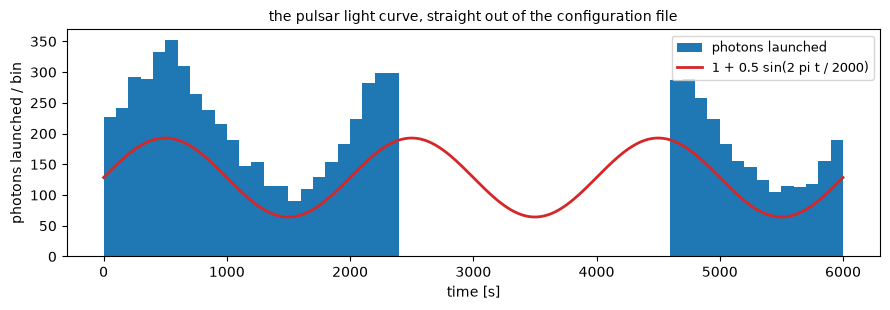

In [10]:
times = u.Quantity([t for t, source, _, _ in events
                    if simulator.source_names[source] == 'pulsar'])

fig, ax = plt.subplots(figsize = (9, 3.2))
ax.hist(times.to_value(u.s), bins = 60, range = (0, 6000),
        color = 'tab:blue', label = 'photons launched')

# The shape the expression asks for, scaled to the mean bin height.
t_grid = np.linspace(0, 6000, 400)
ax.plot(t_grid, (len(times)/60)*(1 + 0.5*np.sin(2*np.pi*t_grid/2000)),
        color = 'tab:red', lw = 2, label = '1 + 0.5 sin(2 pi t / 2000)')

ax.set_xlabel('time [s]'); ax.set_ylabel('photons launched / bin')
ax.set_title('the pulsar light curve, straight out of the configuration file',
             fontsize = 10)
ax.legend(fontsize = 9)
fig.tight_layout()

Three periods in 6000 s, peak-to-trough a factor of three, and the counts
follow the curve the file asked for. The scaling is evaluated **once per
interval, at the interval's midpoint** -- so the histogram follows the curve in
100 s steps, not continuously. That is the `.ori` interval semantics from
notebook 05, not an approximation error: the spacecraft history is the time
resolution of the whole simulation.

## 5. What the run recorded

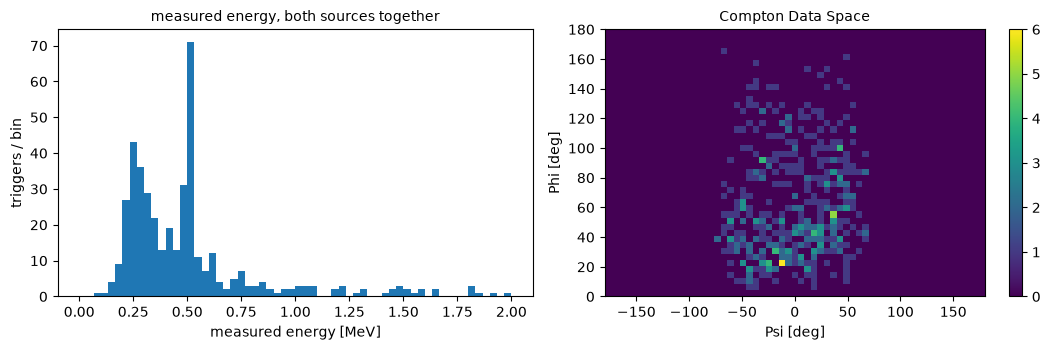

In [11]:
phi_axis = Axis(np.linspace(0, 180, 45)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 60)*u.deg, label = 'Psi')

fig, ax = plt.subplots(figsize = (11, 3.6), ncols = 2)

reco_events = [r for _, _, _, r in events if r.triggered]

ax[0].hist(u.Quantity([r.energy for r in reco_events]).to_value(u.MeV),
           bins = 60, range = (0, 2.0), color = 'tab:blue')
ax[0].set_xlabel('measured energy [MeV]'); ax[0].set_ylabel('triggers / bin')
ax[0].set_title('measured energy, both sources together', fontsize = 10)

h = Histogram([psi_axis, phi_axis])
h.fill(u.Quantity([r.psi for r in reco_events]).to(u.deg),
       u.Quantity([r.phi for r in reco_events]).to(u.deg),
       warn_overflow = False)
h.plot(ax[1])
ax[1].set_title('Compton Data Space', fontsize = 10)

fig.tight_layout()

The 511 keV line is the albedo and the continuum under it is the pulsar's
power law -- two sources, one instrument, one file. Neither is labelled in that
histogram, and that is the honest picture: the instrument does not know which
photon came from where.

The simulation does, though, because the file gave both sources a `name`. That
is what names in a configuration are *for*, and it is the one piece of ground
truth that has no other way of reaching you:

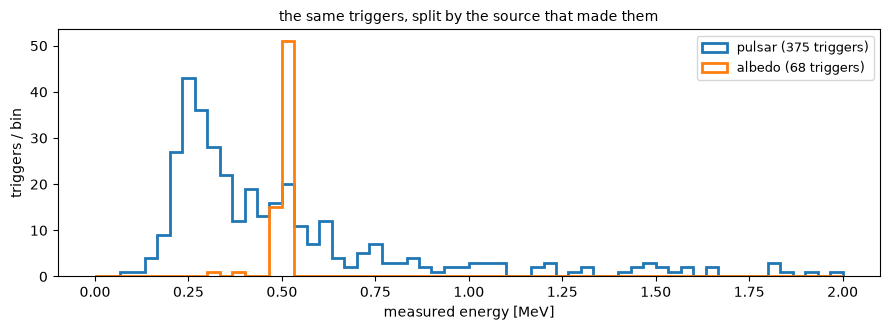

In [12]:
fig, ax = plt.subplots(figsize = (9, 3.4))

for name, colour in [('pulsar', 'tab:blue'), ('albedo', 'tab:orange')]:
    energies = u.Quantity([r.energy for _, s, _, r in events
                           if r.triggered and simulator.source_names[s] == name])
    ax.hist(energies.to_value(u.MeV), bins = 60, range = (0, 2.0),
            histtype = 'step', lw = 2, color = colour,
            label = f'{name} ({len(energies)} triggers)')

ax.set_xlabel('measured energy [MeV]'); ax.set_ylabel('triggers / bin')
ax.set_title('the same triggers, split by the source that made them', fontsize = 10)
ax.legend(fontsize = 9)
fig.tight_layout()

## 6. Writing it back out

`to_config` is the other direction, and it writes a **canonical**
configuration: keys left at their default are omitted, quantities are written
in the unit they are held in, and aliases are resolved to one spelling. So the
file that comes out is not textually the file that went in -- it is the same
run, said one way.

In [13]:
written = simulator.to_config()
print(yaml.safe_dump(written, sort_keys = False))

detector:
  type: ToyTracker2D
  material: Ge
  layer_length: 10.0 m
  layer_positions: '[300.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0] cm'
  layer_thickness: 1.0 cm
  energy_resolution: 0.03
  energy_threshold: 20.0 keV
earth:
  radius: 6371.0 km
reconstructor:
  type: SimpleTraditionalReconstructor
spacecraft_history:
  type: elliptical_orbit
  semi_major_axis: 6771.0 km
  duration: 6000.0 s
  time_step: 100.0 s
  observation_strategy:
    type: ZenithPointing
random_seed: 0
sources:
- name: pulsar
  type: PointSource
  sky_angle: 45.0 deg
  flux: 0.002 1 / (cm s)
  spectrum:
    type: PowerLaw
    index: -2.0
    min_energy: 0.2 MeV
    max_energy: 10.0 MeV
  scaling:
    type: Function
    expression: 1 + 0.5*sin(2*pi*t/2000)
- name: albedo
  type: EarthAlbedoSource
  emissivity: 0.0006 1 / (cm s)
  law: isotropic
  spectrum:
    type: Monoenergetic
    energy: 511.0 keV



Differences from what was written by hand, all of them canonicalization:
`reconstructor` is now explicit (it was defaulted), numbers carry the `.0`
astropy formats them with, and the `Monoenergetic` spectrum is spelled out.

The test that matters is not "does it match the input" but **"is it a fixed
point"** -- read it back, write it again, and get the same thing:

In [14]:
again = InertialSimulator.from_config(written).to_config()
print("to_config(from_config(to_config(...))) is unchanged:", again == written)

# And it survives a real YAML round trip, not just a dict comparison.
reloaded = yaml.safe_load(yaml.safe_dump(written))
print("survives safe_dump/safe_load:",
      InertialSimulator.from_config(reloaded).to_config() == written)

to_config(from_config(to_config(...))) is unchanged: True
survives safe_dump/safe_load: True


Two things in that file cannot be recovered from the objects at all, and so
they ride on the configuration the simulator was built from rather than being
read back off the run:

- **the spacecraft history's provenance.** A `SpacecraftHistory` generated from
  orbital elements keeps its sampled rows, not the elements; one read from an
  `.ori` file does not remember the file.
- **the source names.** A `PointSource` has no name attribute; the name is a
  label the configuration attaches to it.

A simulator built by hand has neither, so `to_config` refuses rather than
inventing them:

In [15]:
detector = ToyTracker2D(material = 'Ge', layer_length = 10*u.m,
                        layer_positions = np.append(300, np.arange(0, 10, 1))*u.cm,
                        layer_thickness = 1*u.cm, energy_resolution = 0.03,
                        energy_threshold = 20*u.keV)
earth = Earth(radius = 6371*u.km)
by_hand = InertialSimulator(
    detector = detector,
    sources = [PointSource(sky_angle = 45*u.deg, flux = 1e-3*u.Unit('1/(cm s)'),
                           spectrum = MonoenergeticSpectrum(511*u.keV))],
    spacecraft_history = SpacecraftHistory.from_elliptical_orbit(
        semi_major_axis = earth.radius + 400*u.km, duration = 6000*u.s,
        time_step = 100*u.s, earth = earth,
        observation_strategy = ZenithPointing()),
    earth = earth,
    reconstructor = SimpleTraditionalReconstructor())

try:
    by_hand.to_config()
except ValueError as err:
    print(err)

this simulator's spacecraft history was not built by `from_config`, so there is nothing to write for it: a generated `SpacecraftHistory` keeps its sampled rows, not the orbital elements that produced them, and one read from a file does not remember the file.


## 7. `random_seed`, and why it is applied last

`random_seed: 0` in the file seeds numpy's global generator, so the same file
gives the same run. The subtlety is *when* it is applied: **last**, as the
final act of `from_config`, after every object has been built.

That is not cosmetic. Building the configuration draws random numbers itself in
places, and anything drawn between seeding and running would shift the stream.
Seeding last means the state of the world before `from_config` cannot reach the
run at all -- which is exactly what the test below deliberately tries to make
it do:

In [16]:
# A tenth of the orbit: the point is that two runs agree, and that costs
# nothing to show at 600 s.
seed_config = copy.deepcopy(base)
seed_config['spacecraft_history']['duration'] = '600 s'

def run_summary(config):
    sim = InertialSimulator.from_config(config)
    return [(t.to_value(u.s), p.energy.to_value(u.keV),
             p.direction.to_value(u.deg))
            for t, _, p, _ in sim.run_events(progress = False)]

first = run_summary(seed_config)

# Disturb the global RNG as violently as is convenient before the second run.
np.random.seed(999)
np.random.uniform(size = 37)

second = run_summary(seed_config)

print(f"{len(first)} events each")
print("byte-identical:", first == second)

2308 events each
byte-identical: True


## 8. The event file

The last link. Notebook 05 introduced `write_event_csv`, whose metadata header
carries a run's provenance so that a file and its data cannot drift apart. With
a configured run there is finally something worth putting in `source_names`:

In [17]:
event_path = os.path.join(scratch, 'events.csv')
write_event_csv(event_path, events,
                source_names = simulator.source_names,
                total_livetime = simulator.spacecraft_history.total_livetime,
                spacecraft_history = simulator.spacecraft_history)

metadata, table = read_event_csv(event_path)

print(f"{len(table)} rows")
print(table['source'].value_counts().to_string())
print()
print("metadata keys:", sorted(metadata))

13414 rows
source
pulsar    7710
albedo    5704

metadata keys: ['gammaraytoys_version', 'nsim', 'ori_file', 'total_livetime_s', 'triggered_only']


And that closes the loop this series set out to draw. The YAML file says what
was simulated, the event file says what came out and carries the run's
provenance with it, and neither one needs the notebook that produced it in
order to be read.

What is *not* here is worth saying plainly. The configuration layer is a
loader, not a framework: it has no console script, no plugin registry, and no
schema-validation dependency. Every type it knows is a name in a dictionary in
`gammaraytoys/sims/config.py`, and adding one is a `*_from_config` /
`*_to_config` pair next to the others. That is the whole extension mechanism,
and for a teaching package it is the right size.